# Exploratory Text Analysis (EDA)

In this Notebook we try to understand the text in our dataset. Exploratory Text Analysis bridges the gap between raw data and modeling by revealing patterns, vocabulary differences, and structural characteristics that directly inform our approach in later chapters.

This chapter uses `review_cleaned` (aggressive version) throughout, as the goal here is thematic exploration, not sentiment prediction.

**In this Notebook, we explore the following:**

| Section | Analysis |
|---|---|
| 3.1 | Review length distribution by sentiment |
| 3.2 | Top unigrams: overall, positive, negative |
| 3.3 | WordClouds: positive vs negative |
| 3.4 | Bigrams and Trigrams |
| 3.5 | Vocabulary richness |
| 3.6 | Review length vs helpfulness |
| 3.7 | Early Access Analysis |

**Note on preprocessing:** Our aggressive pipeline preserves negation words (not, no, never, dont, cant etc.) and sentiment words (great,
terrible, love, awful etc.), removing only platform meta words and meaningless filler. This means our EDA reflects genuine vocabulary patterns rather than artificially stripped text.

### Load Notebook 2 Output & Install Dependencies

We load the preprocessed dataset saved at the end of Notebook 2 (text_preprocessing).
We also ensure the WordCloud library is available, installing it
if necessary.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from nltk.util import ngrams

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_parquet('../data/steam_text_mining_nb2.parquet')

print(f"Loaded successfully")
print(f"Rows    : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")

Loaded successfully
Rows    : 919,083
Columns : ['review', 'recommended', 'votes_helpful', 'written_during_early_access', 'author.playtime_at_review', 'author.num_reviews', 'app_name', 'app_id', 'playtime_hours', 'review_cleaned', 'review_cleaned_sentiment', 'word_count_raw', 'word_count_cleaned', 'word_count_conservative']


### 3.1 Review Length Distribution by Sentiment

In this section, we check whether positive
and negative reviewers write differently in terms of length. Longer reviews
may indicate more invested players who feel strong enough to elaborate,
while shorter reviews may reflect impulsive reactions.

We compare the distribution of cleaned word counts between recommended
(positive) and not recommended (negative) reviews using both a histogram
and summary statistics.

We use `word_count_cleaned` from the aggressive pipeline for this comparison.

In [29]:
pos_reviews = df[df['recommended'] == True]['word_count_cleaned']
neg_reviews = df[df['recommended'] == False]['word_count_cleaned']

print("Review Length by Sentiment\n")
print(pd.DataFrame({
    'Positive (True)' : pos_reviews.describe(),
    'Negative (False)': neg_reviews.describe()
}).round(2))

Review Length by Sentiment

       Positive (True)  Negative (False)
count        804234.00         114849.00
mean             18.34             34.97
std              40.58             61.45
min               1.00              1.00
25%               3.00              6.00
50%               6.00             14.00
75%              17.00             37.00
max            2000.00           1600.00


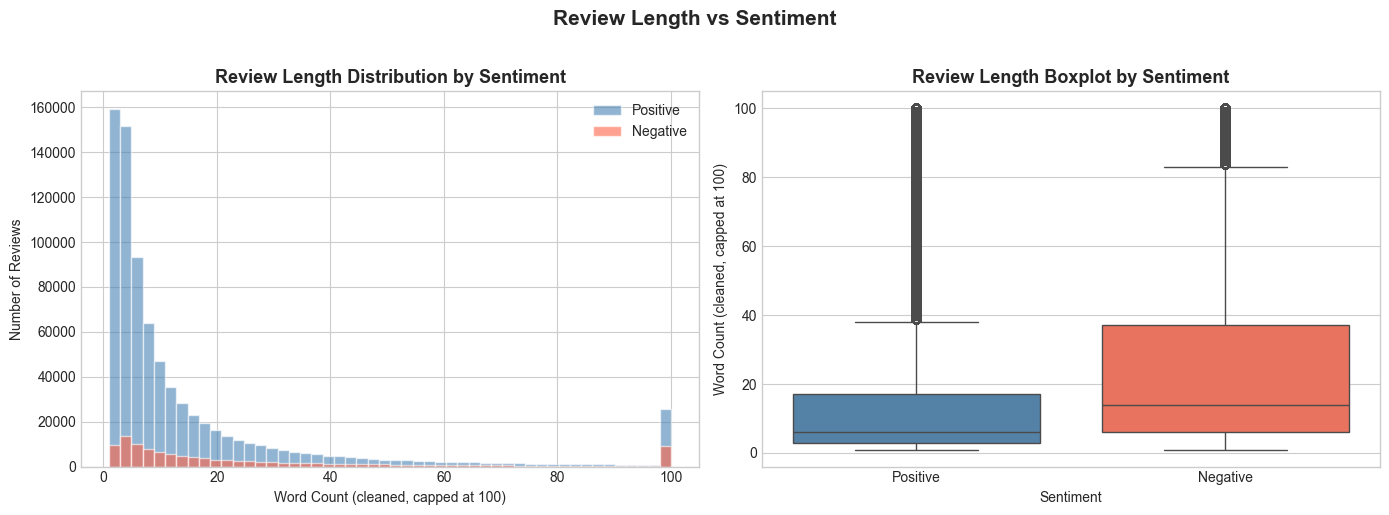

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(pos_reviews.clip(upper=100), bins=50,
             alpha=0.6, color='steelblue', label='Positive', edgecolor='white')
axes[0].hist(neg_reviews.clip(upper=100), bins=50,
             alpha=0.6, color='tomato', label='Negative', edgecolor='white')
axes[0].set_title('Review Length Distribution by Sentiment', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count (cleaned, capped at 100)')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

# Boxplot
df_plot = df[['recommended', 'word_count_cleaned']].copy()
df_plot['recommended'] = df_plot['recommended'].map({True: 'Positive', False: 'Negative'})
df_plot['word_count_cleaned'] = df_plot['word_count_cleaned'].clip(upper=100)

sns.boxplot(data=df_plot, x='recommended', y='word_count_cleaned',
            hue='recommended',
            palette={'Positive': 'steelblue', 'Negative': 'tomato'},
            legend=False,
            ax=axes[1])
axes[1].set_title('Review Length Boxplot by Sentiment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count (cleaned, capped at 100)')

plt.suptitle('Review Length vs Sentiment', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Unigrams: Most Frequent Single Words

Unigram frequency analysis reveals the most commonly used words across
the entire dataset and separately within positive and negative reviews.

Comparing the top words between positive and negative reviews is one of
the most direct ways to identify vocabulary differences between the two
groups. Words that appear heavily in one group but not the other are
strong signals for both topic modeling and sentiment classification.

We display the top 20 words for each group as horizontal bar charts.

In [31]:
def get_top_words(text_series, n=20):
    all_words = ' '.join(text_series.dropna()).split()
    word_freq  = Counter(all_words)
    top_words  = pd.DataFrame(word_freq.most_common(n),
                               columns=['word', 'count'])
    return top_words


top_overall  = get_top_words(df['review_cleaned'], n=20)

top_positive = get_top_words(
    df[df['recommended'] == True]['review_cleaned'], n=20)
top_negative = get_top_words(
    df[df['recommended'] == False]['review_cleaned'], n=20)

print("Top 20 words Overall:")
print(top_overall)

Top 20 words Overall:
         word   count
0         not  248832
1        like  230174
2        good  210008
3       great  158665
4        dont  115010
5        best  109940
6       story   95147
7        love   90785
8      friend   82851
9         new   74150
10        buy   71850
11      first   71715
12       feel   71685
13       ever   71367
14    amazing   68668
15     better   67664
16   gameplay   61518
17  character   58414
18       cant   57702
19      worth   56160


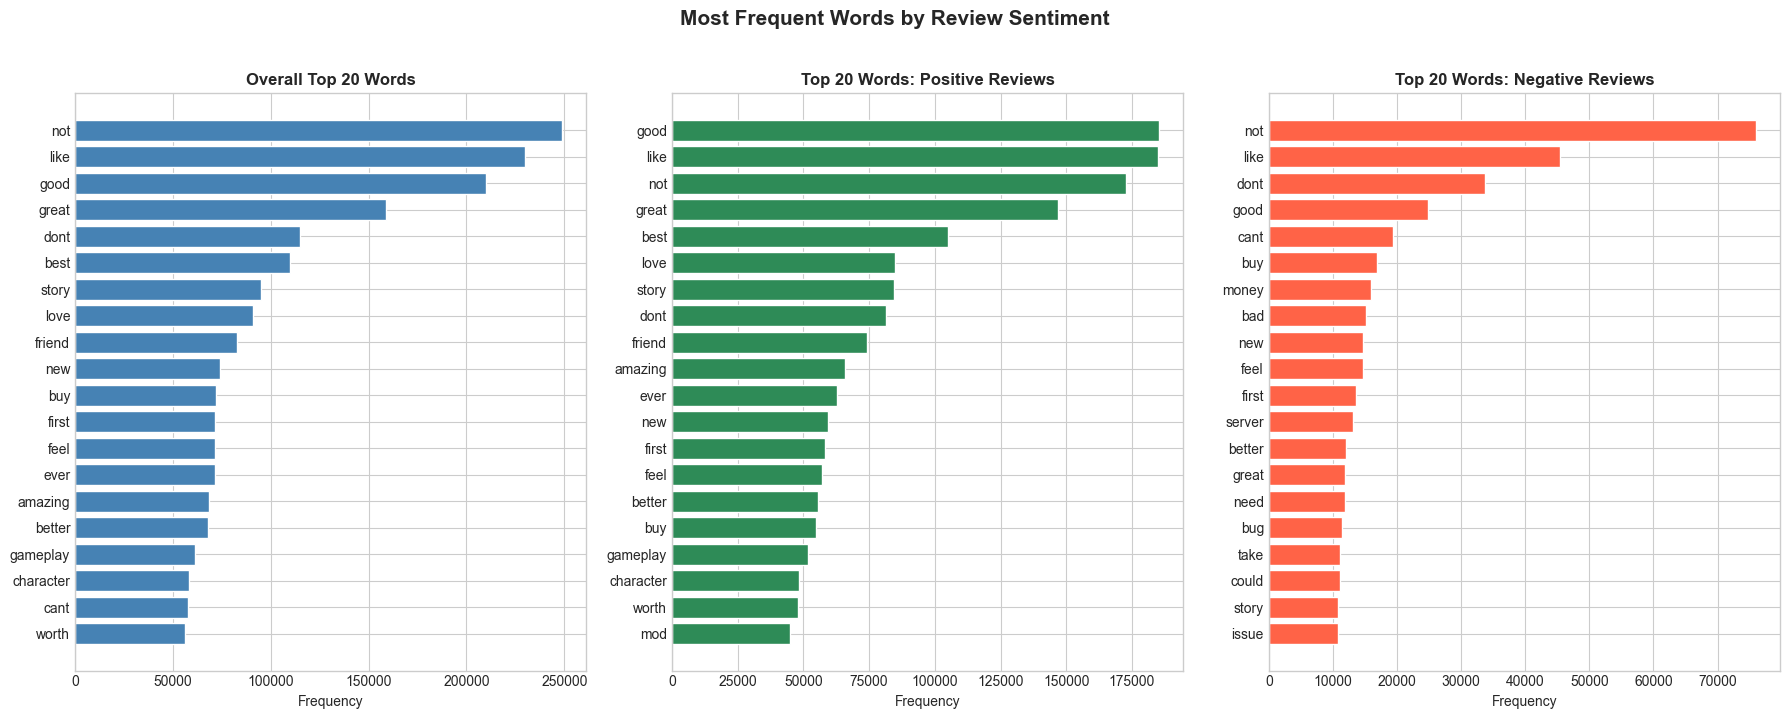

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

datasets = [
    (top_overall,  'Overall Top 20 Words',          'steelblue'),
    (top_positive, 'Top 20 Words: Positive Reviews','seagreen'),
    (top_negative, 'Top 20 Words: Negative Reviews','tomato'),
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.barh(data['word'], data['count'], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.invert_yaxis()

plt.suptitle('Most Frequent Words by Review Sentiment',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 WordClouds: Positive vs Negative Reviews

WordClouds provide an immediate visual summary of the most frequent
vocabulary in each review group. Words that appear more frequently
are rendered larger, making dominant themes instantly visible.

We generate two WordClouds side by side. One for positive reviews
and one for negative to highlight the vocabulary contrast between
players who recommend a game and those who do not.

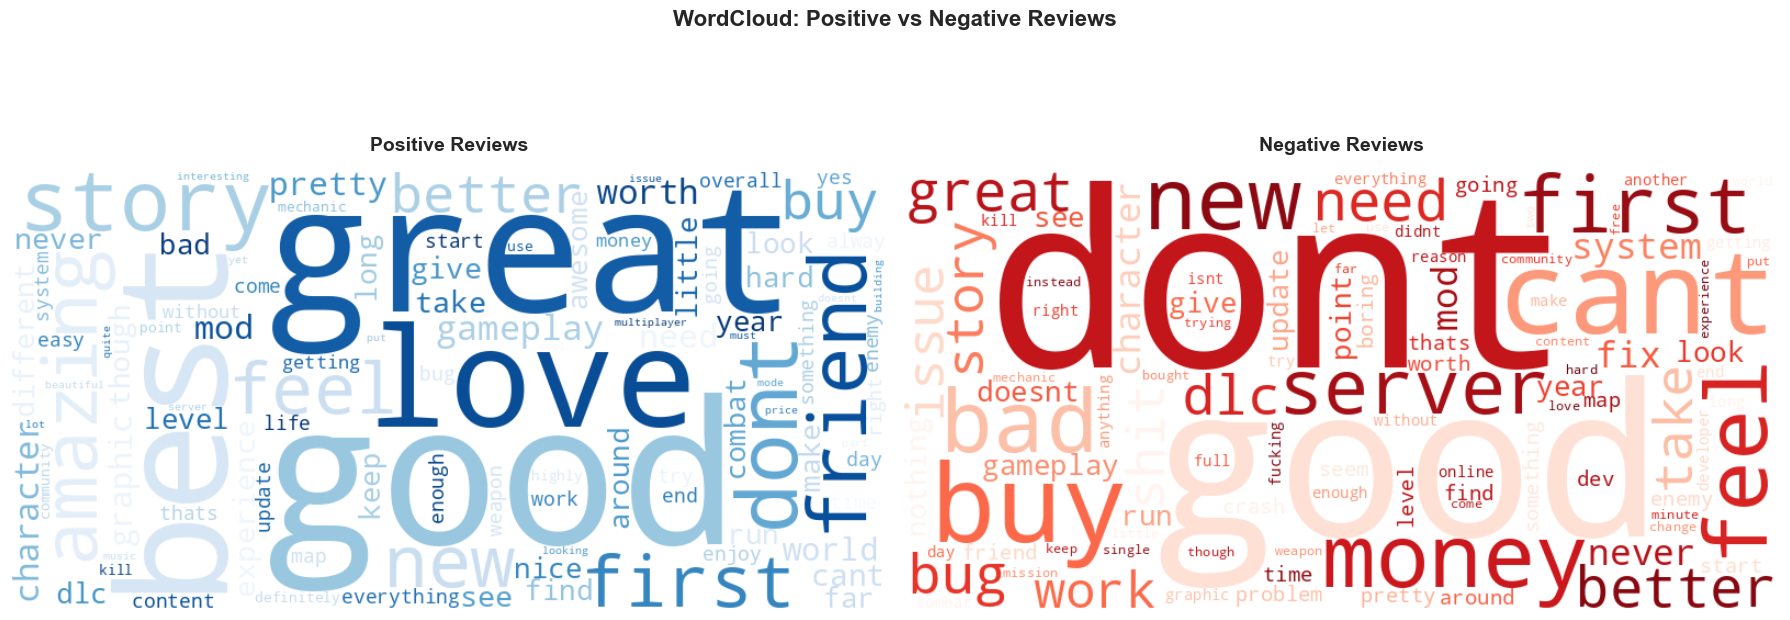

In [33]:
pos_text = ' '.join(df[df['recommended'] == True]['review_cleaned'].dropna())
neg_text = ' '.join(df[df['recommended'] == False]['review_cleaned'].dropna())

wc_pos = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Blues',
    max_words=100,
    collocations=False
).generate(pos_text)

wc_neg = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews', fontsize=14, fontweight='bold', pad=15)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('WordCloud: Positive vs Negative Reviews',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Bigrams and Trigrams (Multi-Word Phrases)

Single words often lose context. Bigrams (2-word phrases) and trigrams
(3-word phrases) capture richer patterns that unigrams miss entirely.

We extract the top 20 bigrams and trigrams separately for positive and
negative reviews to identify the most common multi-word expressions
players use when recommending or criticizing a game.

In [34]:
def get_top_ngrams(text_series, n=2, top_k=20):
    all_ngrams = []
    for text in text_series.dropna():
        tokens = text.split()
        all_ngrams.extend(list(ngrams(tokens, n)))

    ngram_freq = Counter(all_ngrams)
    top        = ngram_freq.most_common(top_k)
    return pd.DataFrame(
        [(' '.join(ng), cnt) for ng, cnt in top],
        columns=['ngram', 'count']
    )

# Bigrams
bi_pos = get_top_ngrams(df[df['recommended'] == True]['review_cleaned'],  n=2)
bi_neg = get_top_ngrams(df[df['recommended'] == False]['review_cleaned'], n=2)

# Trigrams
tri_pos = get_top_ngrams(df[df['recommended'] == True]['review_cleaned'],  n=3)
tri_neg = get_top_ngrams(df[df['recommended'] == False]['review_cleaned'], n=3)

print("Top 20 Bigrams Positive:")
print(bi_pos)

Top 20 Bigrams Positive:
               ngram  count
0          best ever  20129
1          feel like  17772
2      monika monika  10657
3        pretty good   9325
4       early access   8983
5            yes yes   8789
6          dark soul   8260
7         open world   7289
8          cant wait   6728
9          dont like   6136
10       worth money   5607
11         total war   5447
12         good good   5386
13           buy buy   4735
14       great story   4644
15    learning curve   4597
16           not bad   4302
17        full price   4206
18         art style   3986
19  definitely worth   3923


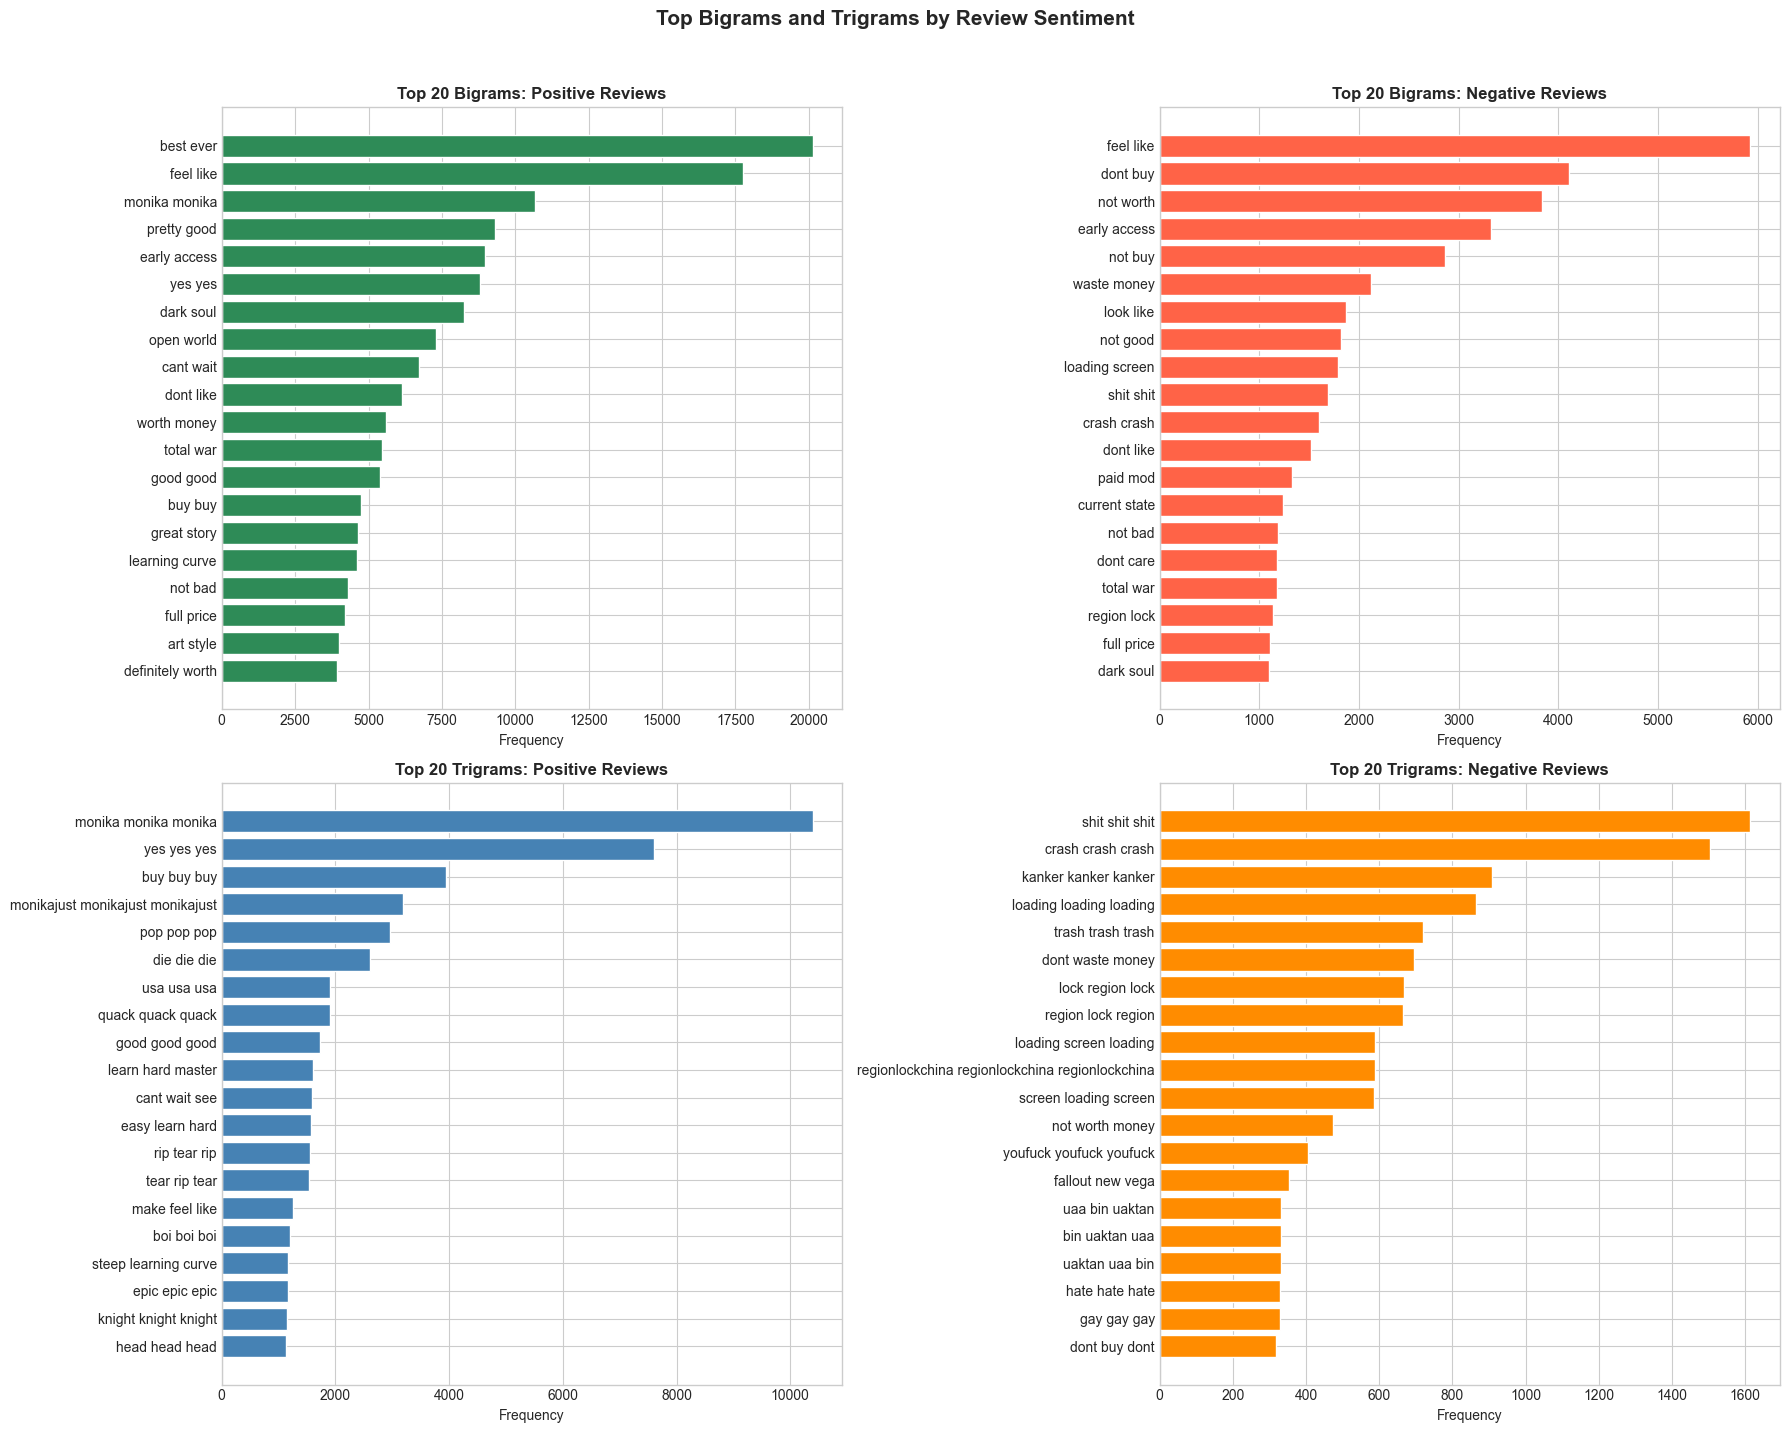

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

datasets = [
    (bi_pos,  'Top 20 Bigrams: Positive Reviews', 'seagreen',  axes[0][0]),
    (bi_neg,  'Top 20 Bigrams: Negative Reviews', 'tomato',    axes[0][1]),
    (tri_pos, 'Top 20 Trigrams: Positive Reviews', 'steelblue', axes[1][0]),
    (tri_neg, 'Top 20 Trigrams: Negative Reviews', 'darkorange',axes[1][1]),
]

for data, title, color, ax in datasets:
    ax.barh(data['ngram'], data['count'], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.invert_yaxis()

plt.suptitle('Top Bigrams and Trigrams by Review Sentiment',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Vocabulary Richness

Vocabulary richness measures how diverse a reviewer's word choices are.
A common metric is the **Type-Token Ratio (TTR)**, the number of unique
words (types) divided by total words (tokens) in a review.

* **High TTR**: writer uses varied, diverse vocabulary
* **Low TTR**: writer repeats the same words frequently

We compare average TTR between positive and negative reviewers to
determine whether one group tends to write with more linguistic variety.
We also look at overall unique vocabulary size across the full dataset.

In [36]:
def type_token_ratio(text):
    tokens = text.split()
    if len(tokens) == 0:
        return 0
    return len(set(tokens)) / len(tokens)

df['ttr'] = df['review_cleaned'].apply(type_token_ratio)

print("Type Token Ratio by Sentiment\n")
print(df.groupby('recommended')['ttr'].describe().round(4))

# Overall vocabulary size
all_words       = ' '.join(df['review_cleaned'].dropna()).split()
unique_words    = set(all_words)
print(f"\nTotal words (tokens)  : {len(all_words):,}")
print(f"Unique words (types)  : {len(unique_words):,}")
print(f"Overall vocabulary TTR: {len(unique_words)/len(all_words):.4f}")

Type Token Ratio by Sentiment

                count    mean     std     min     25%     50%  75%  max
recommended                                                            
False        114849.0  0.9274  0.0957  0.0006  0.8750  0.9667  1.0  1.0
True         804234.0  0.9565  0.0875  0.0005  0.9375  1.0000  1.0  1.0

Total words (tokens)  : 18,764,542
Unique words (types)  : 329,652
Overall vocabulary TTR: 0.0176


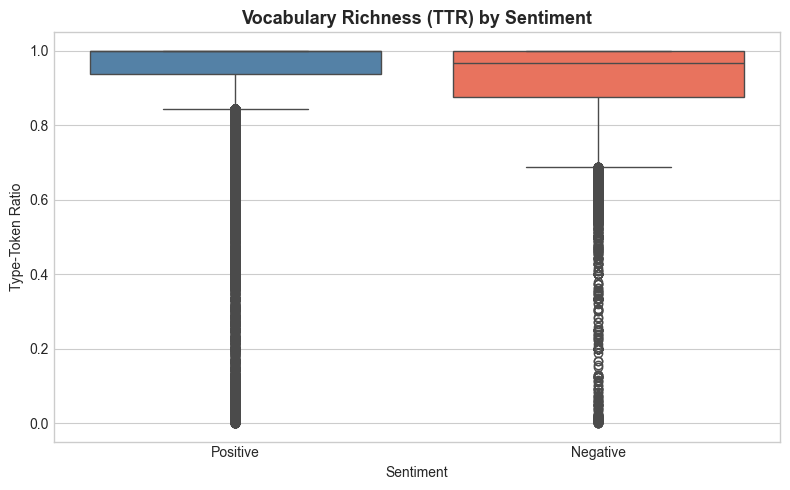

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))

df_ttr = df[['recommended', 'ttr']].copy()
df_ttr['recommended'] = df_ttr['recommended'].map(
    {True: 'Positive', False: 'Negative'})

sns.boxplot(data=df_ttr, x='recommended', y='ttr',
            hue='recommended',
            palette={'Positive': 'steelblue', 'Negative': 'tomato'},
            legend=False,
            ax=ax)
ax.set_title('Vocabulary Richness (TTR) by Sentiment',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Type-Token Ratio')
plt.tight_layout()
plt.show()

### 3.6 Review Length vs Helpfulness

A natural hypothesis is that longer, more detailed reviews are perceived as more helpful by the community. Here we test this directly by comparing the word count distribution of helpful reviews (votes_helpful ≥ 1) against unhelpful reviews (votes_helpful = 0).

We also compute the average word count at different helpfulness thresholds to see if the relationship holds across varying levels of community approval.

In [38]:
df['is_helpful'] = (df['votes_helpful'] >= 1).astype(int)

print("Word Count by Helpfulness\n")
print(df.groupby('is_helpful')['word_count_cleaned'].describe().round(2))

Word Count by Helpfulness

               count   mean    std  min  25%   50%   75%     max
is_helpful                                                      
0           623481.0  15.71  33.10  1.0  3.0   6.0  15.0  2000.0
1           295602.0  30.34  59.88  1.0  4.0  10.0  30.0  1876.0


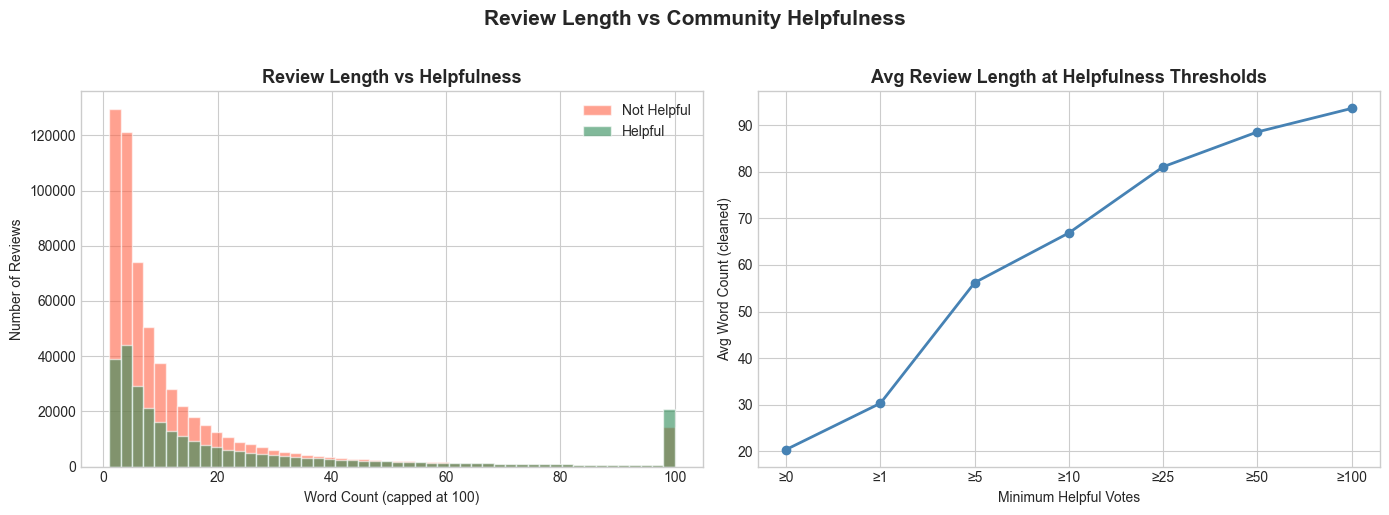

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

helpful     = df[df['is_helpful'] == 1]['word_count_cleaned']
not_helpful = df[df['is_helpful'] == 0]['word_count_cleaned']

axes[0].hist(not_helpful.clip(upper=100), bins=50,
             alpha=0.6, color='tomato', label='Not Helpful', edgecolor='white')
axes[0].hist(helpful.clip(upper=100), bins=50,
             alpha=0.6, color='seagreen', label='Helpful', edgecolor='white')
axes[0].set_title('Review Length vs Helpfulness', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count (capped at 100)')
axes[0].set_ylabel('Number of Reviews')
axes[0].legend()

thresholds  = [0, 1, 5, 10, 25, 50, 100]
avg_lengths = [
    df[df['votes_helpful'] >= t]['word_count_cleaned'].mean()
    for t in thresholds
]

axes[1].plot(range(len(thresholds)), avg_lengths,
             marker='o', color='steelblue', linewidth=2)
axes[1].set_xticks(range(len(thresholds)))
axes[1].set_xticklabels([f'≥{t}' for t in thresholds])
axes[1].set_title('Avg Review Length at Helpfulness Thresholds',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Minimum Helpful Votes')
axes[1].set_ylabel('Avg Word Count (cleaned)')

plt.suptitle('Review Length vs Community Helpfulness',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.7 Early Access vs Full Release Reviews

Early access reviews are written while the game is still in development. Players who review during early access are engaging with an unfinished product, which may significantly influence their vocabulary, sentiment, and recommendation behavior compared to players reviewing a finished game.

We analyze three things:
1. How many reviews are from early access vs full release
2. Whether early access reviews differ in recommendation rate
3. Whether early access reviews differ in length and vocabulary

Early Access Distribution

                              count  percent
written_during_early_access                 
False                        821652     89.4
True                          97431     10.6


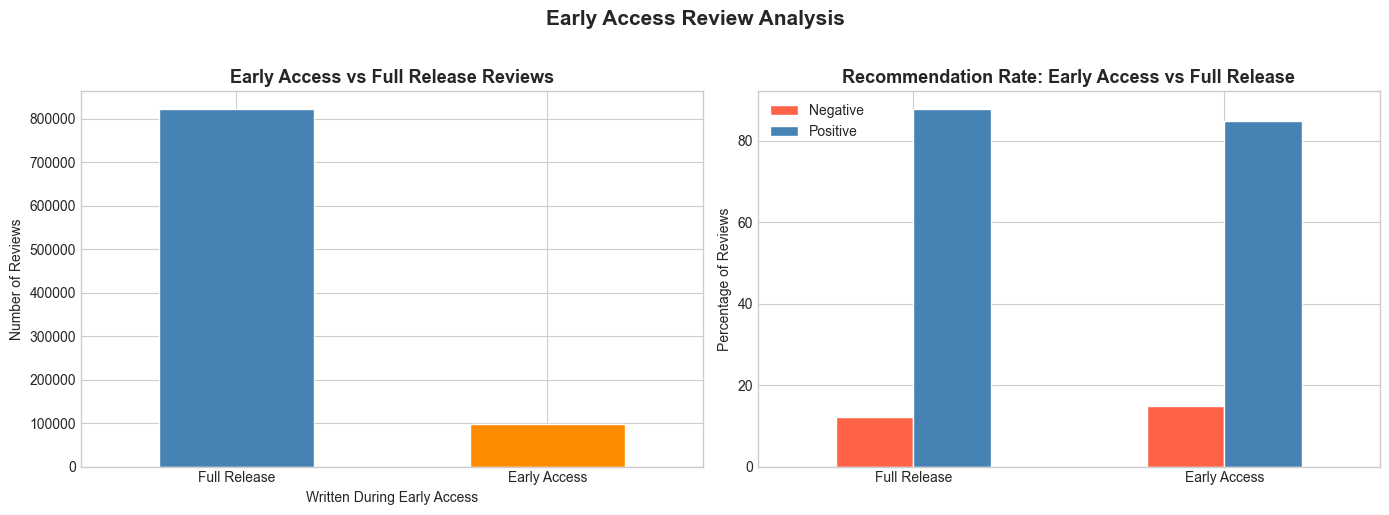

In [40]:
print("Early Access Distribution\n")

ea_counts = df['written_during_early_access'].value_counts()
ea_pct    = df['written_during_early_access'].value_counts(
                normalize=True).mul(100).round(1)

print(pd.DataFrame({'count': ea_counts, 'percent': ea_pct}))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ea_counts.plot(kind='bar', color=['steelblue', 'darkorange'],edgecolor='white', ax=axes[0])
axes[0].set_title('Early Access vs Full Release Reviews',fontsize=13, fontweight='bold')
axes[0].set_xlabel('Written During Early Access')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticklabels(['Full Release', 'Early Access'], rotation=0)

# Recommendation rate by early access
rec_by_ea = df.groupby('written_during_early_access')['recommended']\
              .value_counts(normalize=True)\
              .mul(100).round(1)\
              .unstack()
rec_by_ea.index = ['Full Release', 'Early Access']
rec_by_ea.columns = ['Negative', 'Positive']

rec_by_ea.plot(kind='bar', color=['tomato', 'steelblue'], edgecolor='white', ax=axes[1])
axes[1].set_title('Recommendation Rate: Early Access vs Full Release', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Percentage of Reviews')
axes[1].set_xticklabels(['Full Release', 'Early Access'], rotation=0)
axes[1].legend(['Negative', 'Positive'])

plt.suptitle('Early Access Review Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

We now compare review length between early access and full release reviewers. Early access players may write longer reviews since they are actively tracking development progress, or shorter reviews since the game is incomplete and harder to fully evaluate.

Review Length: Early Access vs Full Release

       Early Access  Full Release
count      97431.00     821652.00
mean          22.65         20.15
std           43.15         44.18
min            1.00          1.00
25%            4.00          3.00
50%            9.00          7.00
75%           23.00         18.00
max         1005.00       2000.00


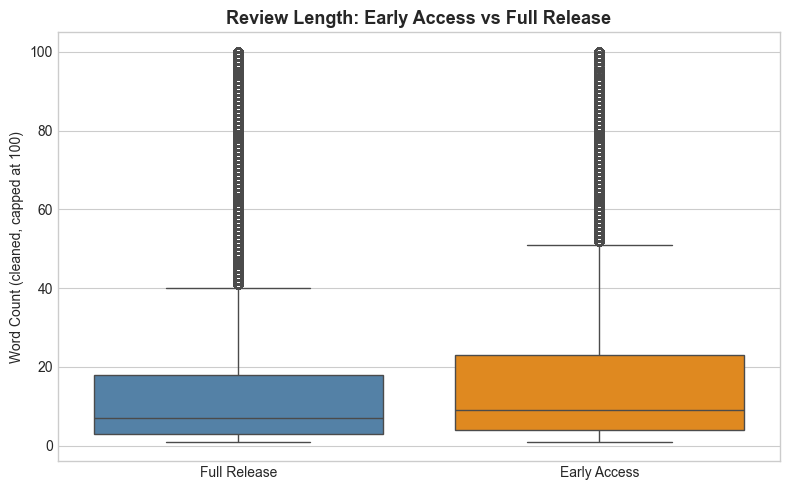

In [44]:
ea_length   = df[df['written_during_early_access'] == True]['word_count_cleaned']
full_length = df[df['written_during_early_access'] == False]['word_count_cleaned']

print("Review Length: Early Access vs Full Release\n")
print(pd.DataFrame({
    'Early Access' : ea_length.describe(),
    'Full Release' : full_length.describe()
}).round(2))

fig, ax = plt.subplots(figsize=(8, 5))

df_plot = df[['written_during_early_access', 'word_count_cleaned']].copy()
df_plot['written_during_early_access'] = df_plot['written_during_early_access']\
    .map({True: 'Early Access', False: 'Full Release'})
df_plot['word_count_cleaned'] = df_plot['word_count_cleaned'].clip(upper=100)

sns.boxplot(data=df_plot,
            x='written_during_early_access',
            y='word_count_cleaned',
            hue='written_during_early_access',
            palette={'Early Access': 'darkorange', 'Full Release': 'steelblue'},
            legend=False,
            ax=ax)
ax.set_title('Review Length: Early Access vs Full Release', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Word Count (cleaned, capped at 100)')
plt.tight_layout()
plt.show()

Finally, we compare the most frequently used words in early access reviews versus full release reviews. This reveals whether early access players focus on different aspects of the game, such as bugs, potential,and development progress. Compared to players reviewing a finished product.

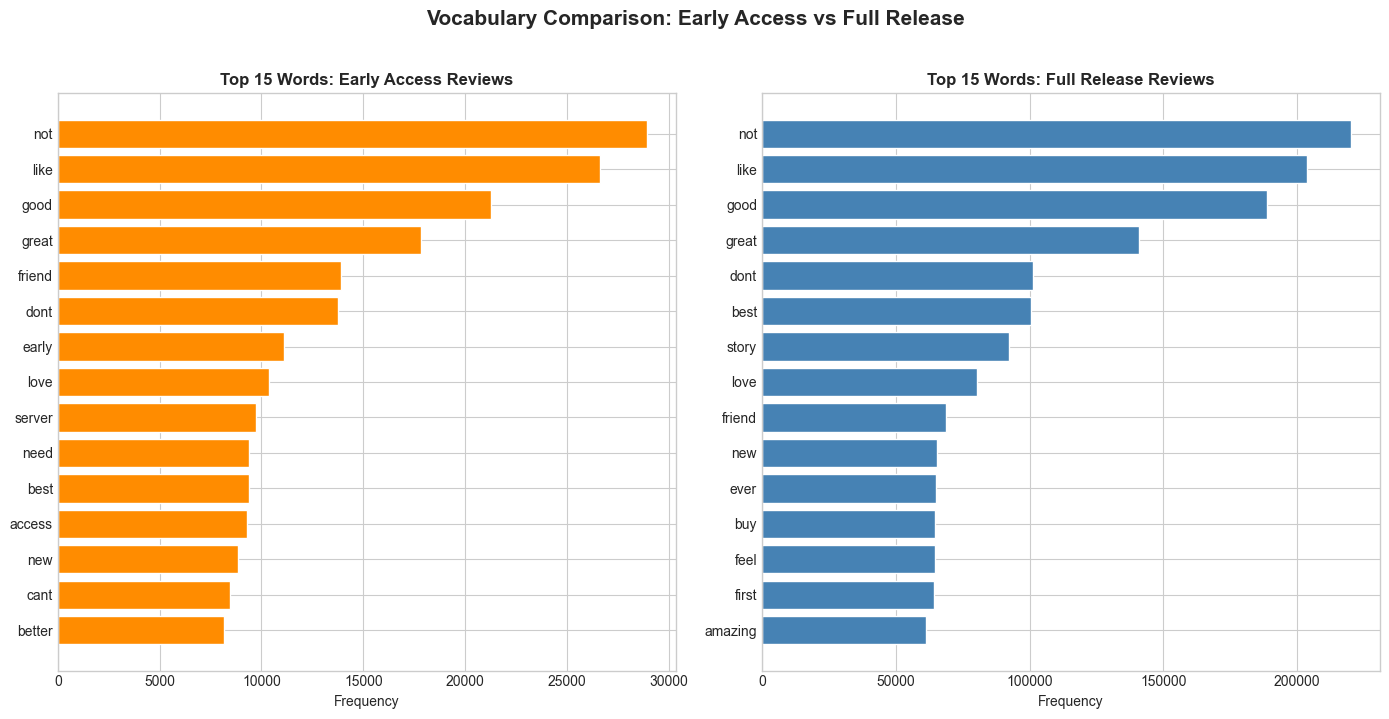

In [42]:
from collections import Counter

def get_top_words(text_series, n=15):
    all_words = ' '.join(text_series.dropna()).split()
    return pd.DataFrame(
        Counter(all_words).most_common(n),
        columns=['word', 'count']
    )

top_ea   = get_top_words(
    df[df['written_during_early_access'] == True]['review_cleaned'])
top_full = get_top_words(
    df[df['written_during_early_access'] == False]['review_cleaned'])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(top_ea['word'], top_ea['count'],
             color='darkorange', edgecolor='white')
axes[0].set_title('Top 15 Words: Early Access Reviews',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

axes[1].barh(top_full['word'], top_full['count'],
             color='steelblue', edgecolor='white')
axes[1].set_title('Top 15 Words: Full Release Reviews',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.suptitle('Vocabulary Comparison: Early Access vs Full Release',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Save Notebook 3 Checkpoint

We save the updated dataframe which now includes the derived columns `is_helpful` and `ttr` computed during EDA. These columns will be reused directly in Chapter 5 during feature engineering, so saving them here avoids redundant computation later.

In [43]:
output_path = '../data/steam_text_mining_nb3.parquet'
df.to_parquet(output_path, index=False)

print(f"Chapter 3 checkpoint saved : steam_text_mining_ch3.parquet")
print(f"Rows    : {len(df):,}")
print(f"Columns : {df.columns.tolist()}")
print(f"Size    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Chapter 3 checkpoint saved : steam_text_mining_ch3.parquet
Rows    : 919,083
Columns : ['review', 'recommended', 'votes_helpful', 'written_during_early_access', 'author.playtime_at_review', 'author.num_reviews', 'app_name', 'app_id', 'playtime_hours', 'review_cleaned', 'review_cleaned_sentiment', 'word_count_raw', 'word_count_cleaned', 'word_count_conservative', 'ttr', 'is_helpful']
Size    : 624.7 MB


## EDA Summary

| Section | Analysis | Key Finding |
|---|---|---|
| 3.1 | Review length by sentiment | Negative reviews are ~2x longer (median 14 vs 6 words) |
| 3.2 | Top unigrams | Negations dominate: "not" is the single most frequent word |
| 3.3 | WordClouds | Clear vocabulary contrast between positive and negative |
| 3.4 | Bigrams & Trigrams | Negation bigrams preserved: "dont like", "not bad" |
| 3.5 | Vocabulary richness (TTR) | Positive reviews show higher TTR (0.957 vs 0.927) |
| 3.6 | Length vs helpfulness | Helpful reviews are ~2x longer (mean 30.3 vs 15.7 words) |
| 3.7 | Early access analysis | Early access reviews are slightly longer and represent 10.6% of data |

**Key Observations:**

1. **Review Length and Sentiment:** Negative reviews are nearly twice as long as positive reviews (median 14 vs 6 words, mean 34.97 vs 18.34 words). Dissatisfied players elaborate significantly more, likely 
detailing specific issues experienced with the game.

2. **Negation Words Are Critical:** With our corrected preprocessing, "not" is the single most frequent word (248,832 occurrences) and "dont" ranks 5th (115,010 occurrences). This validates our decision
   to preserve negation words, removing them would have destroyed the meaning of a large portion of reviews.

3. **Sentiment Vocabulary:** Positive reviews are driven by words like "good" (210,008), "great" (158,665), "love" (90,785) and "amazing" (68,668). Negative reviews are expected to cluster around negation
   phrases like "dont like" (6,136) and "not bad" used sarcastically.

4. **Bigram Artifacts:** Three repetitive bigrams were identified as noise. "monika monika" (10,657) is a game-specific artifact from Doki Doki Literature Club, while "yes yes" (8,789) and "good good"
   (5,386) are repetitive filler phrases. These do not represent meaningful linguistic patterns.

5. **Vocabulary Richness:** Positive reviews have a slightly higher TTR
   (0.957 vs 0.927), though this is partly attributable to their shorter length, shorter texts naturally exhibit higher TTR due to fewer opportunities for word repetition. This is a known limitation of TTR
   as a metric.

6. **Length and Helpfulness:** Reviews receiving at least one helpful vote are nearly twice as long on average (mean 30.3 vs 15.7 words), strongly supporting the hypothesis that detailed, elaborate reviews
   are perceived as more valuable by the community. This will be used as a feature in Notebook 5.

7. **Early Access Reviews:** Only 10.6% of reviews (97,431) were written during early access. These reviews are slightly longer on average
   (mean 22.65 vs 20.15 words, median 9 vs 7 words), suggesting early access players are marginally more elaborate, likely tracking development progress and commenting on unfinished features.

**Output:** `steam_text_mining_nb3.parquet`